<a href="https://colab.research.google.com/github/hiraljoshi93/Machine_Learning/blob/main/05_no_WDF_PC1_score_test80_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scenario 05 - PC1 score only (no WDF)

| Setting | Value |
|---------|-------|
| **WDF** | Excluded |
| **Features** | Uses **PC1 score** from PCA (fit on train) + month + lags. |
| **Split** | **80% train / 20% test** (time-based) |
| **Metrics** | RMSE and R2 |

WDF excluded - recommended for honest reporting.

Run: Runtime -> Run all. Browse and upload CSV if prompted.


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")


## Step 1 - Load CSV (browse and upload)


In [2]:
from pathlib import Path

CSV_NAME = "input_vadodara.csv"
PROJECT_DIR = Path("/content/Vadodara_Rainfall_21Jun")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)


def find_or_load_csv() -> Path:
    for path in [PROJECT_DIR / CSV_NAME, Path(CSV_NAME), Path("..") / CSV_NAME]:
        if path.exists():
            print(f"✓ Found CSV: {path}")
            return path
    try:
        from google.colab import files
        print("Browse and select input_vadodara.csv from your computer:")
        uploaded = files.upload()
        if not uploaded:
            raise FileNotFoundError("No file selected.")
        key = CSV_NAME if CSV_NAME in uploaded else next(k for k in uploaded if k.lower().endswith(".csv"))
        dest = PROJECT_DIR / CSV_NAME
        dest.write_bytes(uploaded[key])
        print(f"Saved to {dest}")
        return dest
    except ImportError:
        raise FileNotFoundError(f"Place {CSV_NAME} in {PROJECT_DIR}")


CSV_PATH = find_or_load_csv()


✓ Found CSV: input_vadodara.csv


## Step 2 - Scenario settings


In [3]:
SCENARIO_ID = 5
SCENARIO_SLUG = "no_WDF_PC1_score"
SCENARIO_NAME = "PC1 score only (no WDF)"
FEATURE_STRATEGY = "pc1_scores"
INCLUDE_WDF = False


## Step 3 - Engine


In [4]:

from __future__ import annotations

import warnings
from dataclasses import dataclass
from typing import Any

import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET = "RF"
TEST_FRACTION = 0.20  # 80% train / 20% test (fixed per requirement)
MET_FEATURES_NO_WDF = ["ATE", "CC", "DTR", "MTE", "PET", "RCETO", "VP"]
ALL_MET_FEATURES = MET_FEATURES_NO_WDF + ["WDF"]
MONTH_ORDER = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]
LAG_FEATURES = ["RF_lag1", "RF_lag12"]
MIN_EQUATION_VARS = 4


@dataclass(frozen=True)
class ScenarioConfig:
    scenario_id: int
    slug: str
    name: str
    feature_strategy: str  # all | pc1_scores | pc1_pc2_scores
    include_wdf: bool


SCENARIO_CONFIGS: list[ScenarioConfig] = [
    ScenarioConfig(1, "with_WDF_all_parameters", "All parameters (with WDF)", "all", True),
    ScenarioConfig(2, "with_WDF_PC1_score", "PC1 score only (with WDF)", "pc1_scores", True),
    ScenarioConfig(3, "with_WDF_PC1_PC2_scores", "PC1 + PC2 scores (with WDF)", "pc1_pc2_scores", True),
    ScenarioConfig(4, "no_WDF_all_parameters", "All parameters (no WDF)", "all", False),
    ScenarioConfig(5, "no_WDF_PC1_score", "PC1 score only (no WDF)", "pc1_scores", False),
    ScenarioConfig(6, "no_WDF_PC1_PC2_scores", "PC1 + PC2 scores (no WDF)", "pc1_pc2_scores", False),
]


def compute_metrics(y_true, y_pred) -> dict[str, float]:
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
    }


def non_negative_predictions(y_pred: np.ndarray) -> np.ndarray:
    """Clip predictions at zero — rainfall cannot be negative."""
    return np.maximum(np.asarray(y_pred, dtype=float), 0.0)


def get_candidate_models() -> dict[str, Any]:
    return {
        "1. Ridge Regression (linear)": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
        ]),
        "2. Random Forest": RandomForestRegressor(
            n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
        ),
        "3. Gradient Boosting": GradientBoostingRegressor(
            n_estimators=200, learning_rate=0.05, max_depth=5, random_state=RANDOM_STATE
        ),
        "4. Hist Gradient Boosting": HistGradientBoostingRegressor(
            max_iter=300, learning_rate=0.05, max_depth=6, random_state=RANDOM_STATE
        ),
        "5. SVR (Support Vector)": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR(kernel="rbf", C=10.0, epsilon=0.1)),
        ]),
        "6. Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
        "7. KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsRegressor(n_neighbors=7)),
        ]),
    }


def load_sorted_dataframe(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df["month_num"] = df["Month"].map({m: i + 1 for i, m in enumerate(MONTH_ORDER)})
    return df.sort_values(["Year", "month_num"]).reset_index(drop=True)


def base_met_columns(include_wdf: bool) -> list[str]:
    return ALL_MET_FEATURES.copy() if include_wdf else MET_FEATURES_NO_WDF.copy()


def add_lag_features(df: pd.DataFrame) -> pd.DataFrame:
    work = df.copy()
    work["RF_lag1"] = work[TARGET].shift(1)
    work["RF_lag12"] = work[TARGET].shift(12)
    return work


def fit_pca_on_train(
    train_met: pd.DataFrame,
    n_components: int,
) -> tuple[StandardScaler, PCA]:
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(train_met)
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    pca.fit(X_scaled)
    return scaler, pca


def transform_pca_scores(
    met_df: pd.DataFrame,
    met_cols: list[str],
    scaler: StandardScaler,
    pca: PCA,
) -> pd.DataFrame:
    X_scaled = scaler.transform(met_df[met_cols])
    scores = pca.transform(X_scaled)
    out = pd.DataFrame(index=met_df.index)
    out["PC1"] = scores[:, 0]
    if scores.shape[1] > 1:
        out["PC2"] = scores[:, 1]
    return out


def build_feature_matrix(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    strategy: str,
    include_wdf: bool,
) -> tuple[pd.DataFrame, pd.DataFrame, list[str], str]:
    met_cols = base_met_columns(include_wdf)
    extra = ["month_num"] + LAG_FEATURES

    if strategy == "all":
        features = met_cols + extra
        detail = f"All meteorological columns: {met_cols}"
        return train_df[features], test_df[features], features, detail

    n_comp = 1 if strategy == "pc1_scores" else 2
    scaler, pca = fit_pca_on_train(train_df[met_cols], n_comp)
    train_pc = transform_pca_scores(train_df, met_cols, scaler, pca)
    test_pc = transform_pca_scores(test_df, met_cols, scaler, pca)

    pc_cols = ["PC1"] if strategy == "pc1_scores" else ["PC1", "PC2"]
    features = pc_cols + extra
    detail = (
        f"PCA fitted on train ({', '.join(met_cols)}). "
        f"Using scores: {pc_cols} + season/lags."
    )

    X_train = pd.concat([train_pc[pc_cols], train_df[extra]], axis=1)
    X_test = pd.concat([test_pc[pc_cols], test_df[extra]], axis=1)
    return X_train, X_test, features, detail


def prepare_splits(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    work = add_lag_features(df)
    met_cols = ALL_MET_FEATURES  # superset; WDF dropped per scenario later
    needed = list(set(met_cols + ["month_num"] + LAG_FEATURES + [TARGET]))
    model_df = work.dropna(subset=needed).reset_index(drop=True)

    split_idx = int(len(model_df) * (1 - TEST_FRACTION))
    return model_df.iloc[:split_idx].copy(), model_df.iloc[split_idx:].copy()


def run_scenario(df: pd.DataFrame, config: ScenarioConfig) -> dict[str, Any]:
    train_df, test_df = prepare_splits(df)

    if not config.include_wdf:
        drop = [c for c in ["WDF"] if c in train_df.columns]
        train_df = train_df.drop(columns=drop)
        test_df = test_df.drop(columns=drop)

    X_train, X_test, features, feature_detail = build_feature_matrix(
        train_df, test_df, config.feature_strategy, config.include_wdf
    )
    y_train = train_df[TARGET]
    y_test = test_df[TARGET]

    comparison_rows = []
    for name, model in get_candidate_models().items():
        m = clone(model)
        m.fit(X_train, y_train)
        pred_train = non_negative_predictions(m.predict(X_train))
        pred_test = non_negative_predictions(m.predict(X_test))
        train_m = compute_metrics(y_train, pred_train)
        test_m = compute_metrics(y_test, pred_test)
        comparison_rows.append({
            "Algorithm": name,
            "Train_R2": train_m["R2"],
            "Test_R2": test_m["R2"],
            "Train_RMSE_mm": train_m["RMSE"],
            "Test_RMSE_mm": test_m["RMSE"],
        })

    comparison_df = (
        pd.DataFrame(comparison_rows)
        .set_index("Algorithm")
        .sort_values("Test_RMSE_mm")
    )
    comparison_df["Rank"] = range(1, len(comparison_df) + 1)
    winner = comparison_df.index[0]
    winner_row = comparison_df.loc[winner]

    return {
        "scenario_id": config.scenario_id,
        "slug": config.slug,
        "name": config.name,
        "feature_strategy": config.feature_strategy,
        "include_wdf": config.include_wdf,
        "test_fraction": TEST_FRACTION,
        "feature_detail": feature_detail,
        "features": features,
        "n_train": len(train_df),
        "n_test": len(test_df),
        "train_years": f"{train_df['Year'].min()}–{train_df['Year'].max()}",
        "test_years": f"{test_df['Year'].min()}–{test_df['Year'].max()}",
        "comparison_df": comparison_df,
        "winner": winner,
        "winner_test_r2": winner_row["Test_R2"],
        "winner_test_rmse": winner_row["Test_RMSE_mm"],
        "X_train": X_train,
        "y_train": y_train,
        "X_test": X_test,
        "y_test": y_test,
    }


def build_formula_string(target: str, coefs: pd.Series, intercept: float) -> str:
    parts = [f"{intercept:.4f}"]
    for name, coef in coefs.items():
        sign = "+" if coef >= 0 else "-"
        parts.append(f" {sign} {abs(coef):.4f}×{name}")
    return f"{target} = " + "".join(parts)


def rank_equation_candidates(train_df: pd.DataFrame, include_wdf: bool) -> list[str]:
    """Rank raw columns for equation building (met + month + lags)."""
    met_cols = base_met_columns(include_wdf)
    candidates = met_cols + ["month_num"] + LAG_FEATURES
    corr = train_df[candidates + [TARGET]].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)
    return corr.index.tolist()


def develop_math_equations(
    df: pd.DataFrame,
    include_wdf: bool = False,
    min_vars: int = MIN_EQUATION_VARS,
) -> dict[str, Any]:
    """
    Build linear equations using top-N predictors (all vars down to min_vars).
    Applies non-negative clip on predictions. Selects best by Test RMSE.
    """
    train_df, test_df = prepare_splits(df)
    if not include_wdf:
        train_df = train_df.drop(columns=["WDF"], errors="ignore")
        test_df = test_df.drop(columns=["WDF"], errors="ignore")

    ranked = rank_equation_candidates(train_df, include_wdf)
    max_vars = len(ranked)
    min_vars = min(min_vars, max_vars)

    rows = []
    formulas = {}
    for n in range(max_vars, min_vars - 1, -1):
        vars_n = ranked[:n]
        model = LinearRegression()
        model.fit(train_df[vars_n], train_df[TARGET])
        coefs = pd.Series(model.coef_, index=vars_n)
        pred_train = non_negative_predictions(model.predict(train_df[vars_n]))
        pred_test = non_negative_predictions(model.predict(test_df[vars_n]))
        train_m = compute_metrics(train_df[TARGET], pred_train)
        test_m = compute_metrics(test_df[TARGET], pred_test)
        neg_before = int((model.predict(test_df[vars_n]) < 0).sum())
        formula = build_formula_string(TARGET, coefs, model.intercept_)
        formulas[n] = formula
        rows.append({
            "N_variables": n,
            "Variables": ", ".join(vars_n),
            "Train_R2": round(train_m["R2"], 3),
            "Test_R2": round(test_m["R2"], 3),
            "Test_RMSE_mm": round(test_m["RMSE"], 2),
            "Negative_preds_before_clip": neg_before,
            "Negative_preds_after_clip": 0,
        })

    results_df = pd.DataFrame(rows).sort_values("Test_RMSE_mm")
    best = results_df.iloc[0]
    best_n = int(best["N_variables"])

    return {
        "include_wdf": include_wdf,
        "ranked_variables": ranked,
        "results_df": results_df,
        "best_n_variables": best_n,
        "best_formula": formulas[best_n],
        "best_test_r2": best["Test_R2"],
        "best_test_rmse": best["Test_RMSE_mm"],
        "all_formulas": formulas,
    }


def run_all_scenarios(csv_path: str) -> tuple[list[dict[str, Any]], pd.DataFrame]:
    df = load_sorted_dataframe(csv_path)
    results = [run_scenario(df, cfg) for cfg in SCENARIO_CONFIGS]
    summary = pd.DataFrame([
        {
            "Scenario": r["scenario_id"],
            "File_slug": r["slug"],
            "Feature_Set": r["name"],
            "Train_Test_Split": "80-20",
            "Features": ", ".join(r["features"]),
            "Best_Algorithm": r["winner"],
            "Test_R2": round(r["winner_test_r2"], 3),
            "Test_RMSE_mm": round(r["winner_test_rmse"], 2),
        }
        for r in results
    ])
    return results, summary


## Step 4 - Run scenario (7 algorithms, best by Test RMSE)


SCENARIO 5: PC1 score only (no WDF)
Train/Test: 80% / 20%  |  Strategy: pc1_scores
PCA fitted on train (ATE, CC, DTR, MTE, PET, RCETO, VP). Using scores: ['PC1'] + season/lags.
Features (4): PC1, month_num, RF_lag1, RF_lag12
Train: 1902–1982 (969 mo)
Test:  1982–2002 (243 mo)

WINNER: 2. Random Forest
  Test R2   = 0.736
  Test RMSE = 65.24 mm

=== ALL 7 ALGORITHMS - RMSE & R2 ===


,Train_R2,Test_R2,Train_RMSE_mm,Test_RMSE_mm,Rank
Algorithm,,,,,
2. Random Forest,0.960,0.736,28.373,65.240,1
4. Hist Gradient Boosting,0.898,0.718,45.005,67.446,2
7. KNN,0.733,0.711,72.954,68.319,3
3. Gradient Boosting,0.966,0.679,25.867,71.935,4
5. SVR (Support Vector),0.575,0.641,91.973,76.051,5
1. Ridge Regression (linear),0.569,0.596,92.669,80.762,6
6. Decision Tree,0.962,0.593,27.370,81.013,7


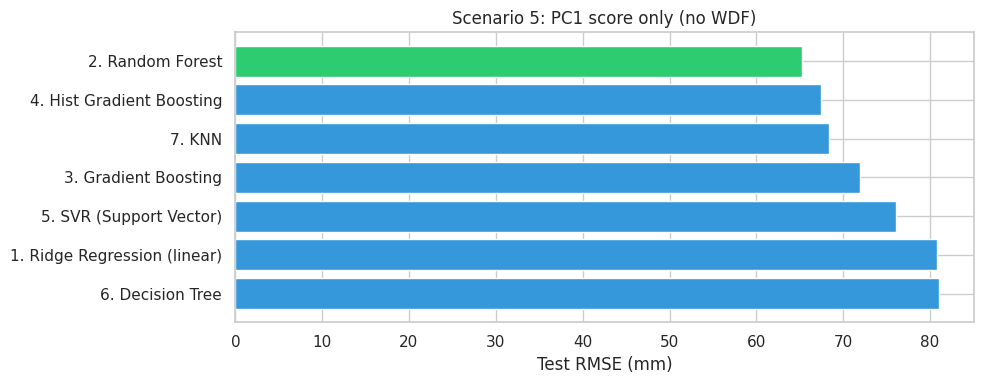

In [5]:
df = load_sorted_dataframe(str(CSV_PATH))
config = ScenarioConfig(
    scenario_id=SCENARIO_ID,
    slug=SCENARIO_SLUG,
    name=SCENARIO_NAME,
    feature_strategy=FEATURE_STRATEGY,
    include_wdf=INCLUDE_WDF,
)
result = run_scenario(df, config)

print("=" * 72)
print(f"SCENARIO {SCENARIO_ID}: {SCENARIO_NAME}")
print(f"Train/Test: 80% / 20%  |  Strategy: {FEATURE_STRATEGY}")
print("=" * 72)
print(result["feature_detail"])
print(f"Features ({len(result['features'])}): {', '.join(result['features'])}")
print(f"Train: {result['train_years']} ({result['n_train']} mo)")
print(f"Test:  {result['test_years']} ({result['n_test']} mo)")
print(f"\nWINNER: {result['winner']}")
print(f"  Test R2   = {result['winner_test_r2']:.3f}")
print(f"  Test RMSE = {result['winner_test_rmse']:.2f} mm")

comparison_df = result["comparison_df"]
print("\n=== ALL 7 ALGORITHMS - RMSE & R2 ===")
display(comparison_df[["Train_R2", "Test_R2", "Train_RMSE_mm", "Test_RMSE_mm", "Rank"]].round(3))

plt.figure(figsize=(10, 4))
order = comparison_df.sort_values("Test_RMSE_mm")
colors = ["#2ecc71" if i == 0 else "#3498db" for i in range(len(order))]
plt.barh(order.index, order["Test_RMSE_mm"], color=colors)
plt.xlabel("Test RMSE (mm)")
plt.title(f"Scenario {SCENARIO_ID}: {SCENARIO_NAME}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
